<a href="https://colab.research.google.com/github/alirezzasarkar/analyze_cryptocurrency/blob/main/technical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install --upgrade tensorflow keras keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.3 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
List of available cryptocurrencies:
1. BTC
2. ETH
3. ADA
4. XRP
5. SOL
Choose a cryptocurrency (number): 1
Selected cryptocurrency: BTC

Select the type of analysis:
1. Short-term (hourly data)
2. Medium-term (daily data)
3. Long-term (daily data)
Enter your choice (1, 2, or 3): 3


[*********************100%***********************]  1 of 1 completed

You selected long-term analysis using daily data.
Fetched data: 
Price            close        high         low        open volumefrom  \
Ticker         BTC-USD     BTC-USD     BTC-USD     BTC-USD    BTC-USD   
Date                                                                    
2014-09-17  457.334015  468.174011  452.421997  465.864014   21056800   
2014-09-18  424.440002  456.859985  413.104004  456.859985   34483200   
2014-09-19  394.795990  427.834991  384.532013  424.102997   37919700   
2014-09-20  408.903992  423.295990  389.882996  394.673004   36863600   
2014-09-21  398.821014  412.425995  393.181000  408.084991   26580100   

Price       volumeto  
Ticker                
Date                  
2014-09-17  21056800  
2014-09-18  34483200  
2014-09-19  37919700  
2014-09-20  36863600  
2014-09-21  26580100  
Last few rows of data: 
Price              close          high           low          open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Da

Reloading Tuner from tuner_dir_gru_base/BTC/gru_base_enhanced/tuner0.json
Epoch 1/50
46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0099
Epoch 1: loss improved from inf to 0.00308, saving model to /content/drive/MyDrive/model_checkpoints/BTC/gru_checkpoint.weights.h5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0096
Epoch 2/50
46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5.0155e-04
Epoch 2: loss improved from 0.00308 to 0.00046, saving model to /content/drive/MyDrive/model_checkpoints/BTC/gru_checkpoint.weights.h5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.9998e-04
Epoch 3/50
45/47 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5.8413e-04
Epoch 3: loss did not improve from 0.00046
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.8133e-04
Epoch 4/50
46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 6.8908e-04
Epoch 4: loss did not improve from 0.00046
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.8392e-04
Epoch 5/50
45/47 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.4522e

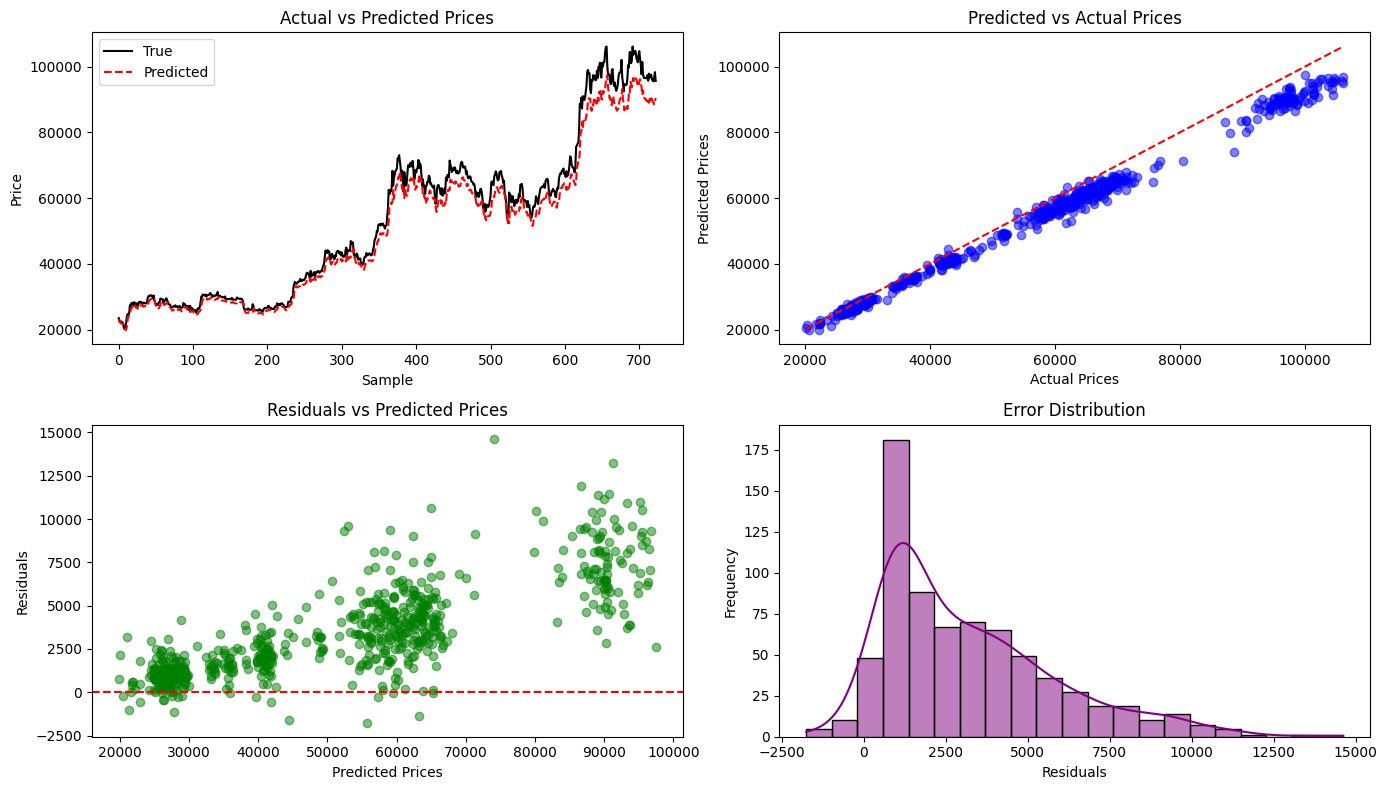


--- Forecasting Future Prices ---

Forecasted Prices:
[89054.25  83531.46  79112.13  75134.78  71377.08  67937.29  64759.316
 61789.027 58994.973 56353.715 53848.137 51466.312 49199.996 47043.59
 44993.41  43047.113 41203.23  39460.86  37819.42  36278.465 34827.21
 33358.42  31861.158 30365.92  28870.008 27417.812 26034.447 24656.182
 23384.41  22255.645]

Last Actual Close Price: 95654.953125
Final Forecast Price: 22255.64453125
Predicted Trend: Downtrend


<ipython-input-7-b5ec99e78fb6>:499: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



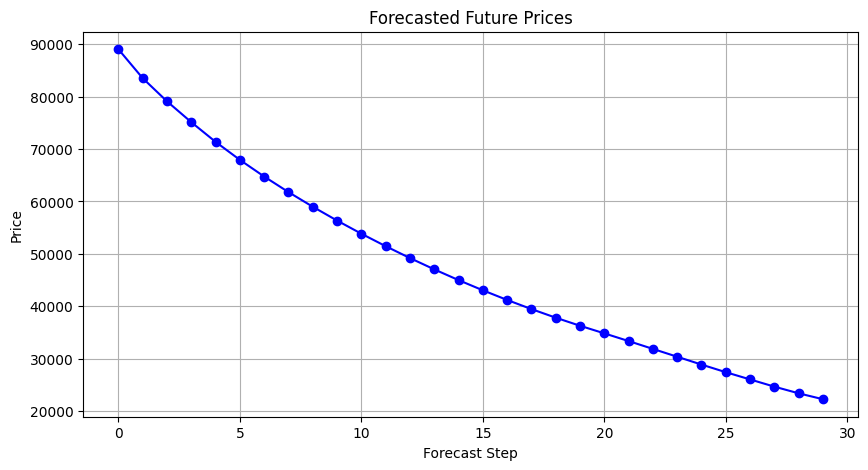

[*********************100%***********************]  1 of 1 completed

Not enough new data for online training. Skipping training step.


In [7]:
# =================== Imports and Libraries ===================
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import TimeSeriesSplit
import plotly.graph_objs as go
import plotly.io as pio
import yfinance as yf
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import logging
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import activations  # Import activations module
import time

# =================== Mount Google Colab Drive (Optional) ===================
from google.colab import drive
drive.mount('/content/drive')

# =================== Set Random Seed for Reproducibility ===================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# =================== Configure Logging ===================
logging.basicConfig(
    filename='model_training.log',
    level=logging.INFO,
    format='%(asctime)s:%(levelname)s:%(message)s'
)
logging.info('Model training process started')

# =================== Configure Plotly ===================
pio.renderers.default = "colab"
pio.templates.default = "plotly_white"

# =================== Define Custom Evaluation Metrics ===================
def mean_absolute_percentage_error_custom(y_true, y_pred):
    # Replace zeros to avoid division by zero
    y_true = np.where(y_true == 0, 1e-8, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

def mean_absolute_scaled_error(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mae_naive = np.mean(np.abs(y_true[1:] - y_true[:-1]))
    return mae / mae_naive

def mase(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mae_naive = mean_absolute_error(y_true[1:], y_true[:-1])
    return mae / mae_naive

# =================== List Available Cryptocurrencies and User Selection ===================
currencies = ['BTC', 'ETH', 'ADA', 'XRP', 'SOL']

print("List of available cryptocurrencies:")
for idx, currency in enumerate(currencies):
    print(f"{idx + 1}. {currency}")

try:
    choice = int(input("Choose a cryptocurrency (number): ")) - 1
    if choice not in range(len(currencies)):
        raise ValueError
except ValueError:
    print("Invalid choice! Please enter a valid number.")
    logging.error("User selected an invalid cryptocurrency choice.")
    exit()

selected_currency = currencies[choice]
print(f"Selected cryptocurrency: {selected_currency}")
logging.info(f"Selected cryptocurrency: {selected_currency}")

# =================== Create Model Directory for Selected Cryptocurrency ===================
model_folder = f'/content/drive/MyDrive/model_checkpoints/{selected_currency}'
if not os.path.exists(model_folder):
    os.makedirs(model_folder)

# =================== Set Tuner Directories for Models ===================
tuner_dir_gru = os.path.join('tuner_dir_gru_base', selected_currency)
tuner_dir_lstm = os.path.join('tuner_dir_lstm_base', selected_currency)
if not os.path.exists(tuner_dir_gru):
    os.makedirs(tuner_dir_gru)
if not os.path.exists(tuner_dir_lstm):
    os.makedirs(tuner_dir_lstm)

# =================== Select Analysis Type ===================
print("\nSelect the type of analysis:")
print("1. Short-term (hourly data)")
print("2. Medium-term (daily data)")
print("3. Long-term (daily data)")

try:
    analysis_choice = int(input("Enter your choice (1, 2, or 3): "))
    if analysis_choice not in [1, 2, 3]:
        raise ValueError
except ValueError:
    print("Invalid choice! Please select 1, 2, or 3.")
    logging.error("User selected an invalid analysis type.")
    exit()

# =================== Set Parameters Based on Analysis Type ===================
if analysis_choice == 1:
    period = "2y"
    interval = "1h"
    sequence_size = 20
    forecast_steps = 12   # Forecasting 12 steps ahead (hourly)
    print("You selected short-term analysis using hourly data.")
    logging.info("Analysis type: Short-term (hourly data)")
elif analysis_choice == 2:
    period = "max"
    interval = "1d"
    sequence_size = 40
    forecast_steps = 7    # Forecasting 7 steps ahead (daily)
    print("You selected medium-term analysis using daily data.")
    logging.info("Analysis type: Medium-term (daily data)")
elif analysis_choice == 3:
    period = "max"
    interval = "1d"
    sequence_size = 40
    forecast_steps = 30   # Forecasting 30 steps ahead (daily)
    print("You selected long-term analysis using daily data.")
    logging.info("Analysis type: Long-term (daily data)")

# =================== Define Yahoo Finance Data Fetching Function with Retry Mechanism ===================
def fetch_data_yfinance(ticker, period, interval, max_retries=5, wait_time=10):
    """
    Fetch historical data from Yahoo Finance with a retry mechanism in case of rate limiting.

    Parameters:
      - ticker: Cryptocurrency ticker (e.g., 'BTC-USD')
      - period: Data period (e.g., '2y' or 'max')
      - interval: Data interval (e.g., '1h' or '1d')
      - max_retries: Maximum number of retry attempts (default: 5)
      - wait_time: Wait time between attempts in seconds (default: 10)

    Returns:
      - DataFrame containing the fetched data, or None if unsuccessful.
    """
    for attempt in range(max_retries):
        try:
            data = yf.download(tickers=ticker, period=period, interval=interval)
            if not data.empty:
                data.rename(columns={
                    'Open': 'open',
                    'High': 'high',
                    'Low': 'low',
                    'Close': 'close',
                    'Volume': 'volumefrom'
                }, inplace=True)
                data['volumeto'] = data['volumefrom']
                logging.info(f"Data successfully downloaded for {ticker}.")
                return data
            else:
                raise Exception("Failed to fetch data from Yahoo Finance.")
        except Exception as e:
            print(f"Error fetching data: {e}")
            logging.error(f"Error fetching data: {e}")
            if "Rate limited" in str(e):
                wait = wait_time * (attempt + 1)
                print(f"Rate limit encountered! Retrying in {wait} seconds... (Attempt {attempt + 1}/{max_retries})")
                time.sleep(wait)
            else:
                break
    print("Max retries reached. Could not fetch data.")
    logging.error("Max retries reached. Could not fetch data.")
    return None

# =================== Define Yahoo Finance Tickers and Fetch Data ===================
yahoo_tickers = {
    'BTC': 'BTC-USD',
    'ETH': 'ETH-USD',
    'ADA': 'ADA-USD',
    'XRP': 'XRP-USD',
    'SOL': 'SOL-USD'
}

selected_ticker = yahoo_tickers[selected_currency]

# Fetch data using the defined function
df = fetch_data_yfinance(selected_ticker, period, interval)
if df is None or df.empty:
    print("Failed to fetch data. Please try again later.")
    exit()

print(f"Fetched data: \n{df.head()}")
print(f"Last few rows of data: \n{df.tail()}")
logging.info(f"First 5 rows of data:\n{df.head()}")
logging.info(f"Last 5 rows of data:\n{df.tail()}")

# =================== Plot Candlestick Chart ===================
fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df['open'],
    high=df['high'],
    low=df['low'],
    close=df['close']
)])
fig.update_layout(
    title=f'Candlestick Chart for {selected_currency}',
    xaxis_title='Date',
    yaxis_title='Price',
    xaxis_rangeslider_visible=False
)
fig.show()
logging.info("Candlestick chart plotted.")

# =================== Split Data into Training and Testing Sets ===================
split_ratio = 0.8
split_index = int(len(df) * split_ratio)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()
df = pd.concat([train_df, test_df]).dropna()

# =================== Normalize Data and Define Features ===================
features = ['open', 'high', 'low', 'close']
scaler = MinMaxScaler()
scaler.fit(train_df[features])
train_scaled = scaler.transform(train_df[features])
test_scaled  = scaler.transform(test_df[features])

# =================== Define Function to Create Multivariate Sequences ===================
def create_multivariate_sequences(dataset, seq_size=1, target_column='close'):
    X, y = [], []
    target_index = features.index(target_column)
    for i in range(len(dataset) - seq_size):
        X.append(dataset[i:i+seq_size])
        y.append(dataset[i+seq_size, target_index])
    return np.array(X), np.array(y)

# =================== Create Sequences for Training and Testing ===================
X_train, y_train = create_multivariate_sequences(train_scaled, seq_size=sequence_size, target_column='close')
X_test,  y_test  = create_multivariate_sequences(test_scaled, seq_size=sequence_size, target_column='close')

# =================== Define Walk-Forward Cross Validation Tuner Class ===================
class WalkForwardCVTuner(kt.BayesianOptimization):
    def run_trial(self, trial, X, y, batch_size=64, epochs=20, **fit_kwargs):
        tscv = TimeSeriesSplit(n_splits=5)
        val_losses = []
        for train_idx, val_idx in tscv.split(X):
            X_train_fold, X_val_fold = X[train_idx], X[val_idx]
            y_train_fold, y_val_fold = y[train_idx], y[val_idx]
            model = self.hypermodel.build(trial.hyperparameters)
            model.compile(optimizer=model.optimizer, loss=model.loss)
            early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            history = model.fit(X_train_fold, y_train_fold,
                                validation_data=(X_val_fold, y_val_fold),
                                epochs=epochs,
                                batch_size=batch_size,
                                callbacks=[early_stopping],
                                verbose=0)
            val_losses.append(min(history.history['val_loss']))
        mean_val_loss = float(np.mean(val_losses))
        self.oracle.update_trial(trial.trial_id, {'val_loss': mean_val_loss})

# =================== Checkpointing Setup ===================
checkpoint_path_gru = os.path.join(model_folder, 'gru_checkpoint.weights.h5')
checkpoint_path_lstm = os.path.join(model_folder, 'lstm_checkpoint.weights.h5')
checkpoint_path_meta = os.path.join(model_folder, 'meta_checkpoint.weights.h5')

checkpoint_callback_gru = ModelCheckpoint(
    filepath=checkpoint_path_gru,
    monitor='loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,
    mode='min'
)
checkpoint_callback_lstm = ModelCheckpoint(
    filepath=checkpoint_path_lstm,
    monitor='loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,
    mode='min'
)
checkpoint_callback_meta = ModelCheckpoint(
    filepath=checkpoint_path_meta,
    monitor='loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,
    mode='min'
)

# =================== Define GRU Base Model Function ===================
def build_gru_base(hp):
    units = hp.Int('units_gru', min_value=64, max_value=512, step=64)
    dropout_rate = hp.Float('dropout_gru', 0.1, 0.5, step=0.1)
    batch_norm_choice = hp.Choice('batch_norm_gru', [True, False])
    learning_rate = hp.Choice('lr_gru', [1e-3, 1e-4, 1e-5])
    inputs = Input(shape=(sequence_size, len(features)))
    x = GRU(units, return_sequences=True)(inputs)
    if batch_norm_choice:
        x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = GRU(units, return_sequences=False)(x)
    if batch_norm_choice:
        x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    feature_output = Dense(50, activation='relu', name='features')(x)
    prediction = Dense(1, activation='linear', name='prediction')(feature_output)
    model = Model(inputs=inputs, outputs=prediction)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# =================== Define LSTM Base Model Function ===================
def build_lstm_base(hp):
    units = hp.Int('units_lstm', min_value=64, max_value=512, step=64)
    dropout_rate = hp.Float('dropout_lstm', 0.1, 0.5, step=0.1)
    batch_norm_choice = hp.Choice('batch_norm_lstm', [True, False])
    learning_rate = hp.Choice('lr_lstm', [1e-3, 1e-4, 1e-5])
    inputs = Input(shape=(sequence_size, len(features)))
    x = LSTM(units, return_sequences=True)(inputs)
    if batch_norm_choice:
        x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = LSTM(units, return_sequences=False)(x)
    if batch_norm_choice:
        x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    feature_output = Dense(50, activation='relu', name='features')(x)
    prediction = Dense(1, activation='linear', name='prediction')(feature_output)
    model = Model(inputs=inputs, outputs=prediction)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# =================== Configure Tuner and Train GRU Model ===================
tuner_gru = WalkForwardCVTuner(
    hypermodel=build_gru_base,
    objective='val_loss',
    max_trials=20,
    directory=os.path.join(tuner_dir_gru),
    project_name='gru_base_enhanced'
)
tuner_gru.search(X_train, y_train, epochs=50, batch_size=64, verbose=1)
best_hps_gru = tuner_gru.get_best_hyperparameters(num_trials=1)[0]
gru_base_model = tuner_gru.hypermodel.build(best_hps_gru)
gru_base_model.compile(optimizer=Adam(learning_rate=best_hps_gru.get('lr_gru')), loss='mse')
gru_base_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True),
               checkpoint_callback_gru]
)

# =================== Configure Tuner and Train LSTM Model ===================
tuner_lstm = WalkForwardCVTuner(
    hypermodel=build_lstm_base,
    objective='val_loss',
    max_trials=20,
    directory=os.path.join(tuner_dir_lstm),
    project_name='lstm_base_enhanced'
)
tuner_lstm.search(X_train, y_train, epochs=50, batch_size=64, verbose=1)
best_hps_lstm = tuner_lstm.get_best_hyperparameters(num_trials=1)[0]
lstm_base_model = tuner_lstm.hypermodel.build(best_hps_lstm)
lstm_base_model.compile(optimizer=Adam(learning_rate=best_hps_lstm.get('lr_lstm')), loss='mse')
lstm_base_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True),
               checkpoint_callback_lstm]
)

# =================== Extract Features from GRU and LSTM Models ===================
# Create feature extractors using the 'features' layer from each model
feature_extractor_gru = Model(inputs=gru_base_model.input, outputs=gru_base_model.get_layer('features').output)
feature_extractor_lstm = Model(inputs=lstm_base_model.input, outputs=lstm_base_model.get_layer('features').output)

features_gru_train = feature_extractor_gru.predict(X_train, verbose=0)
features_lstm_train = feature_extractor_lstm.predict(X_train, verbose=0)
features_gru_test  = feature_extractor_gru.predict(X_test, verbose=0)
features_lstm_test = feature_extractor_lstm.predict(X_test, verbose=0)

# Concatenate features from both models for meta model input
X_train_meta = np.hstack((features_gru_train, features_lstm_train))
X_test_meta = np.hstack((features_gru_test, features_lstm_test))

# =================== Create and Train Meta Model ===================
def build_meta_model():
    inputs = Input(shape=(100,))
    x = Dense(64, activation='relu')(inputs)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    prediction = Dense(1, activation='linear')(x)
    model = Model(inputs=inputs, outputs=prediction)
    model.compile(optimizer=Adam(1e-3), loss='mse')
    return model

meta_model = build_meta_model()
meta_model.fit(
    X_train_meta, y_train,
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True),
               checkpoint_callback_meta]
)

# =================== Predict with Meta Model and Evaluate Metrics ===================
yhat_test_meta = meta_model.predict(X_test_meta, verbose=0).flatten()

def inverse_scale(y_pred, scaler, features):
    y_pred_scaled = np.zeros((len(y_pred), len(features)))
    y_pred_scaled[:, features.index('close')] = y_pred
    return scaler.inverse_transform(y_pred_scaled)[:, features.index('close')]

y_test_inverse = inverse_scale(y_test, scaler, features)
yhat_test_meta_inverse = inverse_scale(yhat_test_meta, scaler, features)

mae_meta  = mean_absolute_error(y_test_inverse, yhat_test_meta_inverse)
mse_meta  = mean_squared_error(y_test_inverse, yhat_test_meta_inverse)
rmse_meta = np.sqrt(mse_meta)
mape_meta = mean_absolute_percentage_error_custom(y_test_inverse, yhat_test_meta_inverse)
r2_meta   = r2_score(y_test_inverse, yhat_test_meta_inverse)
mase_meta = mase(y_test_inverse, yhat_test_meta_inverse)

print("\n--- Stacking Ensemble (Meta Model) ---")
print("MAE:", mae_meta)
print("MSE:", mse_meta)
print("RMSE:", rmse_meta)
print("MAPE:", mape_meta)
print("MASE:", mase_meta)
print("R^2:", r2_meta)

# =================== Plot Results and Visualizations ===================
plt.figure(figsize=(14,8))
plt.subplot(2,2,1)
plt.plot(y_test_inverse, label='True', color='black')
plt.plot(yhat_test_meta_inverse, label='Predicted', linestyle='--', color='red')
plt.title("Actual vs Predicted Prices")
plt.xlabel('Sample')
plt.ylabel('Price')
plt.legend()

plt.subplot(2,2,2)
plt.scatter(y_test_inverse, yhat_test_meta_inverse, alpha=0.5, color='blue')
plt.plot([y_test_inverse.min(), y_test_inverse.max()], [y_test_inverse.min(), y_test_inverse.max()], 'r--')
plt.title("Predicted vs Actual Prices")
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.subplot(2,2,3)
residuals = y_test_inverse - yhat_test_meta_inverse
plt.scatter(yhat_test_meta_inverse, residuals, alpha=0.5, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Prices")
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')

plt.subplot(2,2,4)
sns.histplot(residuals, kde=True, color='purple')
plt.title("Error Distribution")
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# =================== Forecast Future Prices ===================
print("\n--- Forecasting Future Prices ---")
logging.info("Started forecasting future prices")

last_sequence = test_scaled[-sequence_size:]
current_sequence = last_sequence.copy()
forecast_list = []

for i in range(forecast_steps):
    input_seq = np.expand_dims(current_sequence, axis=0)
    features_gru_pred = feature_extractor_gru.predict(input_seq, verbose=0)
    features_lstm_pred = feature_extractor_lstm.predict(input_seq, verbose=0)
    meta_input = np.hstack((features_gru_pred, features_lstm_pred))
    next_close_scaled = meta_model.predict(meta_input, verbose=0)[0, 0]
    forecast_list.append(next_close_scaled)
    new_row = np.array([next_close_scaled, next_close_scaled, next_close_scaled, next_close_scaled])
    current_sequence = np.vstack((current_sequence[1:], new_row))

forecast_scaled_array = np.array([[val, val, val, val] for val in forecast_list])
forecast_unscaled = scaler.inverse_transform(forecast_scaled_array)[:, 3]

# Convert to float to resolve ambiguous comparison issues
last_actual_close = float(test_df['close'].iloc[-1])
threshold = 0.01
final_forecast = float(forecast_unscaled[-1])
if final_forecast > last_actual_close * (1 + threshold):
    trend = "Uptrend"
elif final_forecast < last_actual_close * (1 - threshold):
    trend = "Downtrend"
else:
    trend = "Sideways"

print("\nForecasted Prices:")
print(forecast_unscaled)
print(f"\nLast Actual Close Price: {last_actual_close}")
print(f"Final Forecast Price: {final_forecast}")
print(f"Predicted Trend: {trend}")
logging.info(f"Forecasted future prices: {forecast_unscaled}")
logging.info(f"Predicted trend: {trend}")

plt.figure(figsize=(10,5))
plt.plot(forecast_unscaled, marker='o', linestyle='-', color='blue')
plt.title("Forecasted Future Prices")
plt.xlabel("Forecast Step")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# =================== Define Online Training Function for Meta Model ===================
def online_training_step_for_meta(model, ticker, period, interval, scaler, sequence_size, features,
                                  feature_extractor_gru, feature_extractor_lstm,
                                  epochs=1, batch_size=32, checkpoint_path=None):
    """
    This function fetches new data from yfinance, preprocesses it, passes the data
    through the GRU and LSTM feature extractors to form meta features, and updates the meta model.

    Parameters:
      - model: Meta model (Keras model) to update.
      - ticker: Cryptocurrency ticker (e.g., 'BTC-USD').
      - period: Data period for yfinance (e.g., '1d', '5d', '1mo').
      - interval: Data interval (e.g., '1h', '1d').
      - scaler: Pre-fitted scaler for normalization.
      - sequence_size: Sequence length for generating training sequences.
      - features: List of features (e.g., ['open', 'high', 'low', 'close']).
      - feature_extractor_gru: Pre-trained GRU feature extractor.
      - feature_extractor_lstm: Pre-trained LSTM feature extractor.
      - epochs: Number of epochs for training (default: 1).
      - batch_size: Batch size (default: 32).
      - checkpoint_path: (Optional) Path to save model weights after training.

    Returns:
      - history: Training history from model.fit.
    """
    # Fetch new data from yfinance
    new_data_df = yf.download(tickers=ticker, period=period, interval=interval)
    if new_data_df.empty:
        print("No new data fetched from yfinance.")
        return None

    new_data_df.rename(columns={
        'Open': 'open',
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Volume': 'volumefrom'
    }, inplace=True)
    new_data_df['volumeto'] = new_data_df['volumefrom']
    new_data_df = new_data_df.dropna()

    data = new_data_df[features].values
    data_scaled = scaler.transform(data)

    # Check if there is enough data to form at least one sequence
    if len(data_scaled) <= sequence_size:
        print("Not enough new data for online training. Skipping training step.")
        return None

    X_new, y_new = [], []
    target_index = features.index('close')
    for i in range(len(data_scaled) - sequence_size):
        X_new.append(data_scaled[i:i+sequence_size])
        y_new.append(data_scaled[i+sequence_size, target_index])
    X_new, y_new = np.array(X_new), np.array(y_new)

    # Check if sequences were generated
    if X_new.shape[0] == 0:
        print("No sequences generated from new data. Skipping training step.")
        return None

    # Obtain meta features by passing X_new through the GRU and LSTM feature extractors
    features_gru_new = feature_extractor_gru.predict(X_new, verbose=0)
    features_lstm_new = feature_extractor_lstm.predict(X_new, verbose=0)
    X_new_meta = np.hstack((features_gru_new, features_lstm_new))

    history = model.fit(X_new_meta, y_new, epochs=epochs, batch_size=batch_size, verbose=1)

    if checkpoint_path is not None:
        model.save_weights(checkpoint_path)
        print(f"Checkpoint saved at {checkpoint_path}")

    return history

# =================== Example Usage of Online Training Function for Meta Model ===================
online_checkpoint_path = os.path.join(model_folder, 'meta_online_checkpoint.weights.h5')
history = online_training_step_for_meta(model=meta_model,
                                        ticker=selected_ticker,
                                        period='1d',
                                        interval=interval,
                                        scaler=scaler,
                                        sequence_size=sequence_size,
                                        features=features,
                                        feature_extractor_gru=feature_extractor_gru,
                                        feature_extractor_lstm=feature_extractor_lstm,
                                        epochs=5,
                                        batch_size=32,
                                        checkpoint_path=online_checkpoint_path)